In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

In [ ]:
from google.colab import files

In [ ]:
uploaded=files.upload()

Saving staging shipment table.csv to staging shipment table.csv


In [ ]:
df=pd.read_csv('staging shipment table.csv')

In [ ]:
df

,shipment_id,type,date,product_category,origin,O_Country,destination,D_Country,value,freight_cost,customs_clearance_time_days,delivery_status
0,SHP-2024-0001,Export,2024-01-02,Electronics,Mumbai,India,New York,USA,85000,4250,2.1,On-Time
1,SHP-2024-0002,Import,2024-01-03,Textiles,Shanghai,China,Mumbai,India,120000,6000,3.5,On-Time
2,SHP-2024-0003,Export,2024-01-04,Consumer Goods,Mumbai,India,London,UK,45000,2250,1.8,On-Time
3,SHP-2024-0004,Import,2024-01-05,Industrial Equipment,Hamburg,Germany,Mumbai,India,250000,12500,4.2,Delayed
4,SHP-2024-0005,Export,2024-01-06,Electronics,Mumbai,India,Tokyo,Japan,95000,4750,2.5,On-Time
...,...,...,...,...,...,...,...,...,...,...,...,...
699,SHP-2025-0360,Import,2025-12-27,Industrial Equipment,Busan,South Korea,Mumbai,India,342000,17100,5.7,On-Time
700,SHP-2025-0361,Export,2025-12-28,Electronics,Mumbai,India,New York,USA,123500,6175,3.3,On-Time
701,SHP-2025-0362,Import,2025-12-29,Textiles,Shanghai,China,Mumbai,India,182000,9100,4.7,On-Time
702,SHP-2025-0363,Export,2025-12-30,Consumer Goods,Mumbai,India,London,UK,71500,3575,3.0,On-Time


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 704 entries, 0 to 703
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   shipment_id                  704 non-null    object 
 1   type                         704 non-null    object 
 2   date                         704 non-null    object 
 3   product_category             704 non-null    object 
 4   origin                       704 non-null    object 
 5   O_Country                    704 non-null    object 
 6   destination                  704 non-null    object 
 7   D_Country                    704 non-null    object 
 8   value                        704 non-null    int64  
 9   freight_cost                 704 non-null    int64  
 10  customs_clearance_time_days  704 non-null    float64
 11  delivery_status              704 non-null    object 
dtypes: float64(1), int64(2), object(9)
memory usage: 66.1+ KB


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isna().sum()

,0
shipment_id,0
type,0
date,0
product_category,0
origin,0
O_Country,0
destination,0
D_Country,0
value,0
freight_cost,0


In [ ]:
df.dtypes


,0
shipment_id,object
type,object
date,object
product_category,object
origin,object
O_Country,object
destination,object
D_Country,object
value,int64
freight_cost,int64


In [ ]:
df['date']=pd.to_datetime(df['date'])

In [ ]:
df.describe()

,date,value,freight_cost,customs_clearance_time_days
count,704,704.000000,704.000000,704.000000
mean,2025-01-01 05:02:43.636363520,144446.732955,7222.336648,3.743750
min,2024-01-02 00:00:00,35000.000000,1750.000000,1.500000
25%,2024-07-02 18:00:00,78000.000000,3900.000000,3.000000
50%,2025-01-01 00:00:00,116500.000000,5825.000000,3.750000
75%,2025-07-02 06:00:00,198000.000000,9900.000000,4.500000
max,2025-12-31 00:00:00,415000.000000,20750.000000,5.900000
std,NaN,84286.168817,4214.308441,0.962403


In [ ]:
df.corr(numeric_only=True)

,value,freight_cost,customs_clearance_time_days
value,1.000000,1.000000,0.774407
freight_cost,1.000000,1.000000,0.774407
customs_clearance_time_days,0.774407,0.774407,1.000000


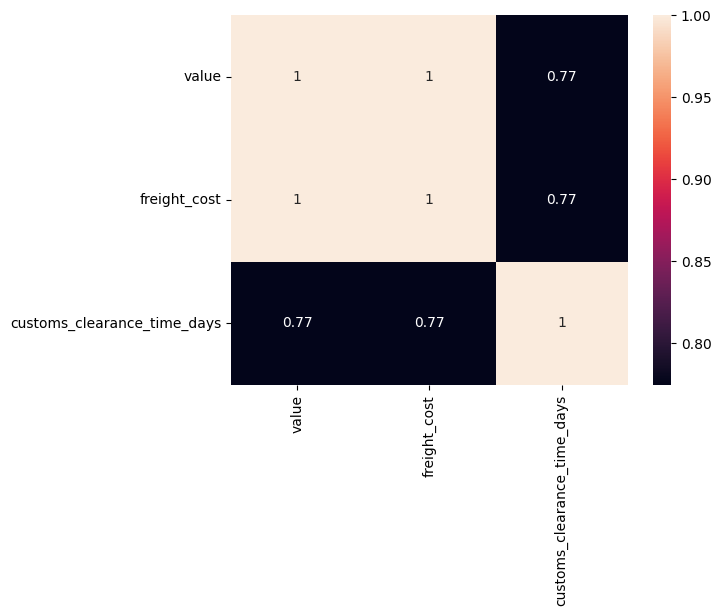

In [ ]:
sns.heatmap(df.corr(numeric_only=True),annot=True,)
plt.rcParams['figure.figsize']=(20,6)
plt.show()

* Value and freight_cost has huge correlation with customs_clearance time days (0.77)

In [ ]:
df

,shipment_id,type,date,product_category,origin,O_Country,destination,D_Country,value,freight_cost,customs_clearance_time_days,delivery_status
0,SHP-2024-0001,Export,2024-01-02,Electronics,Mumbai,India,New York,USA,85000,4250,2.1,On-Time
1,SHP-2024-0002,Import,2024-01-03,Textiles,Shanghai,China,Mumbai,India,120000,6000,3.5,On-Time
2,SHP-2024-0003,Export,2024-01-04,Consumer Goods,Mumbai,India,London,UK,45000,2250,1.8,On-Time
3,SHP-2024-0004,Import,2024-01-05,Industrial Equipment,Hamburg,Germany,Mumbai,India,250000,12500,4.2,Delayed
4,SHP-2024-0005,Export,2024-01-06,Electronics,Mumbai,India,Tokyo,Japan,95000,4750,2.5,On-Time
...,...,...,...,...,...,...,...,...,...,...,...,...
699,SHP-2025-0360,Import,2025-12-27,Industrial Equipment,Busan,South Korea,Mumbai,India,342000,17100,5.7,On-Time
700,SHP-2025-0361,Export,2025-12-28,Electronics,Mumbai,India,New York,USA,123500,6175,3.3,On-Time
701,SHP-2025-0362,Import,2025-12-29,Textiles,Shanghai,China,Mumbai,India,182000,9100,4.7,On-Time
702,SHP-2025-0363,Export,2025-12-30,Consumer Goods,Mumbai,India,London,UK,71500,3575,3.0,On-Time


In [ ]:
df['year']=df['date'].dt.year
df['year']

,year
0,2024
1,2024
2,2024
3,2024
4,2024
...,...
699,2025
700,2025
701,2025
702,2025


In [ ]:
df[['type','O_Country']][df['type']== 'Export'].groupby('O_Country').count()

,type
O_Country,
India,340


In [ ]:
df[['type','D_Country']][df['type']== 'Import'].groupby('D_Country').count()

,type
D_Country,
India,364


* India is the only country which is exporting and importing in this data shipment

In [ ]:
df

,shipment_id,type,date,product_category,origin,O_Country,destination,D_Country,value,freight_cost,customs_clearance_time_days,delivery_status,year
0,SHP-2024-0001,Export,2024-01-02,Electronics,Mumbai,India,New York,USA,85000,4250,2.1,On-Time,2024
1,SHP-2024-0002,Import,2024-01-03,Textiles,Shanghai,China,Mumbai,India,120000,6000,3.5,On-Time,2024
2,SHP-2024-0003,Export,2024-01-04,Consumer Goods,Mumbai,India,London,UK,45000,2250,1.8,On-Time,2024
3,SHP-2024-0004,Import,2024-01-05,Industrial Equipment,Hamburg,Germany,Mumbai,India,250000,12500,4.2,Delayed,2024
4,SHP-2024-0005,Export,2024-01-06,Electronics,Mumbai,India,Tokyo,Japan,95000,4750,2.5,On-Time,2024
...,...,...,...,...,...,...,...,...,...,...,...,...,...
699,SHP-2025-0360,Import,2025-12-27,Industrial Equipment,Busan,South Korea,Mumbai,India,342000,17100,5.7,On-Time,2025
700,SHP-2025-0361,Export,2025-12-28,Electronics,Mumbai,India,New York,USA,123500,6175,3.3,On-Time,2025
701,SHP-2025-0362,Import,2025-12-29,Textiles,Shanghai,China,Mumbai,India,182000,9100,4.7,On-Time,2025
702,SHP-2025-0363,Export,2025-12-30,Consumer Goods,Mumbai,India,London,UK,71500,3575,3.0,On-Time,2025


In [ ]:
#total shipment

total_shipment=df[['shipment_id','type']].groupby('type').count()
total_shipment

,shipment_id
type,
Export,340
Import,364


In [ ]:
fig1=px.histogram(df,x='type',color='year')
fig1.update_layout(bargap=0.1)

In [ ]:
total_shipment.sum()

,0
shipment_id,704


* the total shipent was 704 shipment with 352 shipment in 2024 and the same in 2024

* total export was 340, with 170 in 2024 and the same 2025
* total import 364,with 182 in 2024 and the same in 2025

there was no growth with total shipment

In [ ]:
df

,shipment_id,type,date,product_category,origin,O_Country,destination,D_Country,value,freight_cost,customs_clearance_time_days,delivery_status,year
0,SHP-2024-0001,Export,2024-01-02,Electronics,Mumbai,India,New York,USA,85000,4250,2.1,On-Time,2024
1,SHP-2024-0002,Import,2024-01-03,Textiles,Shanghai,China,Mumbai,India,120000,6000,3.5,On-Time,2024
2,SHP-2024-0003,Export,2024-01-04,Consumer Goods,Mumbai,India,London,UK,45000,2250,1.8,On-Time,2024
3,SHP-2024-0004,Import,2024-01-05,Industrial Equipment,Hamburg,Germany,Mumbai,India,250000,12500,4.2,Delayed,2024
4,SHP-2024-0005,Export,2024-01-06,Electronics,Mumbai,India,Tokyo,Japan,95000,4750,2.5,On-Time,2024
...,...,...,...,...,...,...,...,...,...,...,...,...,...
699,SHP-2025-0360,Import,2025-12-27,Industrial Equipment,Busan,South Korea,Mumbai,India,342000,17100,5.7,On-Time,2025
700,SHP-2025-0361,Export,2025-12-28,Electronics,Mumbai,India,New York,USA,123500,6175,3.3,On-Time,2025
701,SHP-2025-0362,Import,2025-12-29,Textiles,Shanghai,China,Mumbai,India,182000,9100,4.7,On-Time,2025
702,SHP-2025-0363,Export,2025-12-30,Consumer Goods,Mumbai,India,London,UK,71500,3575,3.0,On-Time,2025


In [ ]:
total_shipment_by_product=df[['product_category','type','shipment_id']].groupby(['product_category','type']).count()
total_shipment_by_product

shipment_id
product_category     type               
Consumer Goods       Export           98
                     Import           96
Electronics          Export           98
                     Import           96
Industrial Equipment Export           48
                     Import           98
Textiles             Export           96
                     Import           74

In [ ]:
px.histogram(df,x=['product_category'],color='type',marginal='box')

## export
* India was exporting Electronics and Consumer Goods the most with 98 shipment
* follow by textiles with 96 shipment
* Industrial Equipment was the least product exportated from India

## Import

* India was importing Industrial Equipment the nost with 98 shipment
* follow by Electronics and Consumer Goods  with 96 shipment
* textile were the least product imported

### keys takes aways
* India was exporting Electronics,textiles and Consumer Goods more than they were importing
* India were importing Industrial Equipment more than they were exporting



In [ ]:
df

,shipment_id,type,date,product_category,origin,O_Country,destination,D_Country,value,freight_cost,customs_clearance_time_days,delivery_status,year
0,SHP-2024-0001,Export,2024-01-02,Electronics,Mumbai,India,New York,USA,85000,4250,2.1,On-Time,2024
1,SHP-2024-0002,Import,2024-01-03,Textiles,Shanghai,China,Mumbai,India,120000,6000,3.5,On-Time,2024
2,SHP-2024-0003,Export,2024-01-04,Consumer Goods,Mumbai,India,London,UK,45000,2250,1.8,On-Time,2024
3,SHP-2024-0004,Import,2024-01-05,Industrial Equipment,Hamburg,Germany,Mumbai,India,250000,12500,4.2,Delayed,2024
4,SHP-2024-0005,Export,2024-01-06,Electronics,Mumbai,India,Tokyo,Japan,95000,4750,2.5,On-Time,2024
...,...,...,...,...,...,...,...,...,...,...,...,...,...
699,SHP-2025-0360,Import,2025-12-27,Industrial Equipment,Busan,South Korea,Mumbai,India,342000,17100,5.7,On-Time,2025
700,SHP-2025-0361,Export,2025-12-28,Electronics,Mumbai,India,New York,USA,123500,6175,3.3,On-Time,2025
701,SHP-2025-0362,Import,2025-12-29,Textiles,Shanghai,China,Mumbai,India,182000,9100,4.7,On-Time,2025
702,SHP-2025-0363,Export,2025-12-30,Consumer Goods,Mumbai,India,London,UK,71500,3575,3.0,On-Time,2025


In [ ]:
df

,shipment_id,type,date,product_category,origin,O_Country,destination,D_Country,value,freight_cost,customs_clearance_time_days,delivery_status,year
0,SHP-2024-0001,Export,2024-01-02,Electronics,Mumbai,India,New York,USA,85000,4250,2.1,On-Time,2024
1,SHP-2024-0002,Import,2024-01-03,Textiles,Shanghai,China,Mumbai,India,120000,6000,3.5,On-Time,2024
2,SHP-2024-0003,Export,2024-01-04,Consumer Goods,Mumbai,India,London,UK,45000,2250,1.8,On-Time,2024
3,SHP-2024-0004,Import,2024-01-05,Industrial Equipment,Hamburg,Germany,Mumbai,India,250000,12500,4.2,Delayed,2024
4,SHP-2024-0005,Export,2024-01-06,Electronics,Mumbai,India,Tokyo,Japan,95000,4750,2.5,On-Time,2024
...,...,...,...,...,...,...,...,...,...,...,...,...,...
699,SHP-2025-0360,Import,2025-12-27,Industrial Equipment,Busan,South Korea,Mumbai,India,342000,17100,5.7,On-Time,2025
700,SHP-2025-0361,Export,2025-12-28,Electronics,Mumbai,India,New York,USA,123500,6175,3.3,On-Time,2025
701,SHP-2025-0362,Import,2025-12-29,Textiles,Shanghai,China,Mumbai,India,182000,9100,4.7,On-Time,2025
702,SHP-2025-0363,Export,2025-12-30,Consumer Goods,Mumbai,India,London,UK,71500,3575,3.0,On-Time,2025


In [ ]:
delivery_status_by_type=((df[['delivery_status','type']][df['delivery_status']== 'On-Time'].groupby('type').count()/df[['delivery_status','type']].groupby('type').count())*100).merge((df[['delivery_status','type']][df['delivery_status']== 'Delayed'].groupby('type').count()/df[['delivery_status','type']].groupby('type').count())*100,on='type',how='inner')

delivery_status_by_type.rename(columns={'delivery_status_x':'On-Time Delivery percentage','delivery_status_y':'Delayed Delivery percentage'},inplace=True)

delivery_status_by_type

,On-Time Delivery percentage,Delayed Delivery percentage
type,,
Export,85.294118,14.705882
Import,83.516484,16.483516


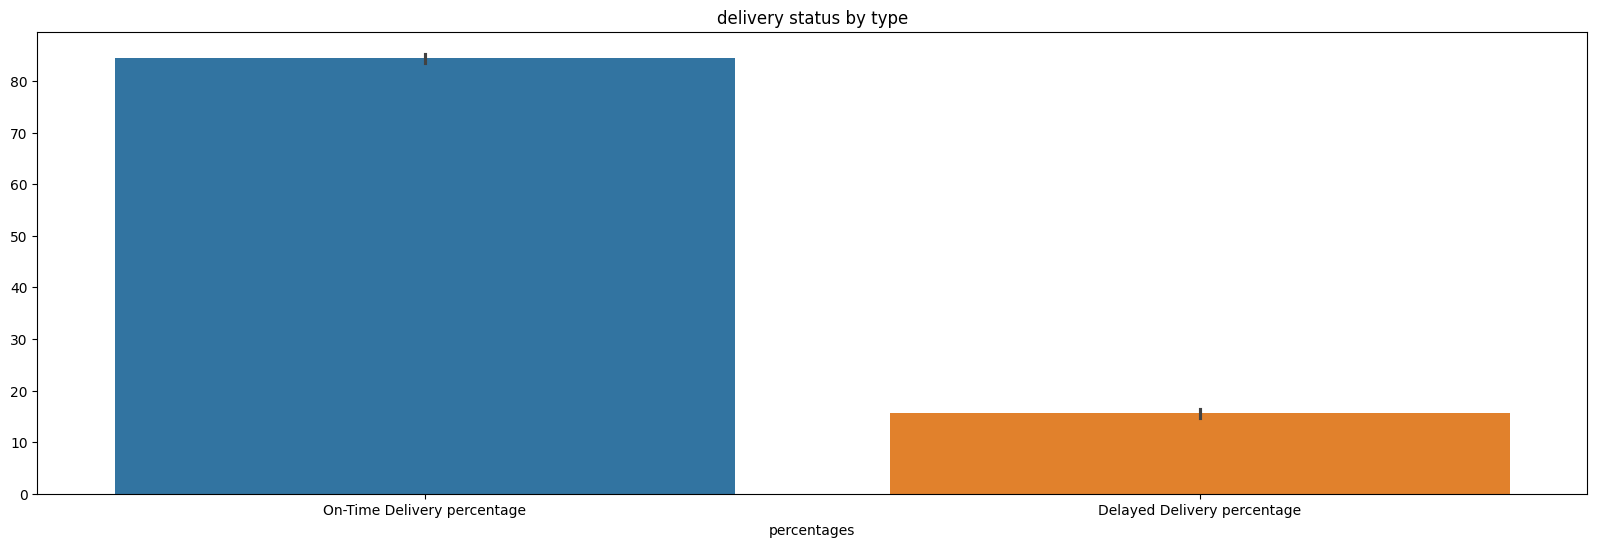

In [ ]:
fig2=sns.barplot(delivery_status_by_type)
plt.title('delivery status by type')
plt.xlabel('percentages')
plt.rcParams['figure.figsize']=(10,7)
plt.show()

## delivery staus
* export: 85.29% of export arrived on-time and 14.70% of export was delayed
* import: 83.51% of import arrived on-time and 16.48% of export was delayed

## keys
* more export shipment arrived on time than import like a difference of 1.78 %

* we need to consider these few delayed to improve the shipment




In [ ]:
delivery_status_by_category=((df[['delivery_status','product_category']][df['delivery_status']=='On-Time' ].groupby('product_category').count()/df[['product_category','delivery_status']].groupby('product_category').count())*100).merge(((df[['delivery_status','product_category']][df['delivery_status']== 'Delayed'].groupby('product_category').count()/df[['product_category','delivery_status']].groupby('product_category').count())*100),on='product_category',how='inner')

delivery_status_by_category.rename(columns={'delivery_status_x':'On-Time Delivery percentage','delivery_status_y':'Delayed Delivery percentage'},inplace=True)
delivery_status_by_category

,On-Time Delivery percentage,Delayed Delivery percentage
product_category,,
Consumer Goods,82.474227,17.525773
Electronics,86.597938,13.402062
Industrial Equipment,84.931507,15.068493
Textiles,83.529412,16.470588


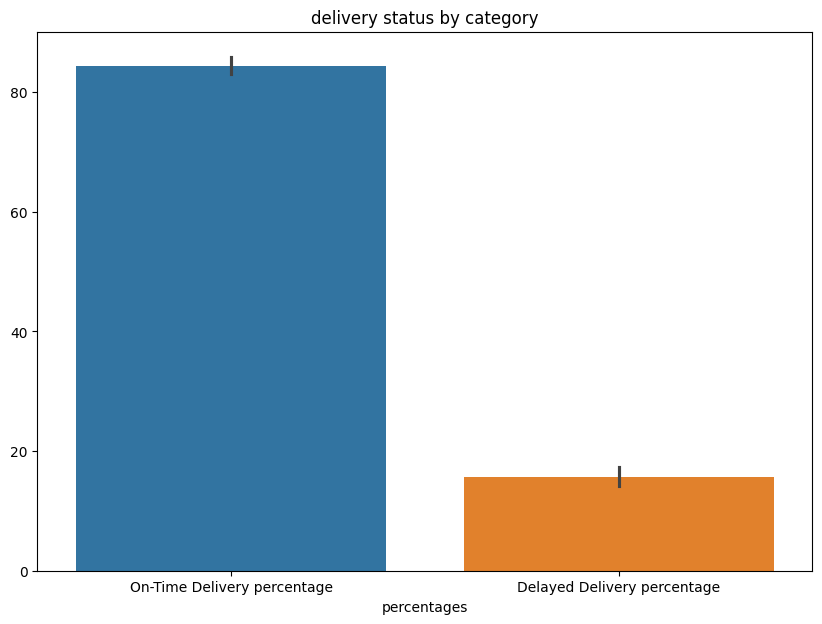

In [ ]:
fig2=sns.barplot(delivery_status_by_category)
plt.title('delivery status by category')
plt.xlabel('percentages')
plt.rcParams['figure.figsize']=(10,7)
plt.show()

### delivery by prucdt catregoty
* consumer goods : 86.59% of consumer goods shipment arrived On-time and 17.52% shipment were delayed
* Electronics : 86.59% of Electronics shipment arrived On-time and 13.40% shipment were delayed
* Industrial Equipent: 84.93% of  Industrial Equipent arrived on-time and 17.06% shipment were delayed
* Textiles : 83.52% of Textiles shipment arrived on-time and 16.47% shipment were delayed

### keys

The company big problem was shimpment delayed

In [ ]:
df

,shipment_id,type,date,product_category,origin,O_Country,destination,D_Country,value,freight_cost,customs_clearance_time_days,delivery_status,year
0,SHP-2024-0001,Export,2024-01-02,Electronics,Mumbai,India,New York,USA,85000,4250,2.1,On-Time,2024
1,SHP-2024-0002,Import,2024-01-03,Textiles,Shanghai,China,Mumbai,India,120000,6000,3.5,On-Time,2024
2,SHP-2024-0003,Export,2024-01-04,Consumer Goods,Mumbai,India,London,UK,45000,2250,1.8,On-Time,2024
3,SHP-2024-0004,Import,2024-01-05,Industrial Equipment,Hamburg,Germany,Mumbai,India,250000,12500,4.2,Delayed,2024
4,SHP-2024-0005,Export,2024-01-06,Electronics,Mumbai,India,Tokyo,Japan,95000,4750,2.5,On-Time,2024
...,...,...,...,...,...,...,...,...,...,...,...,...,...
699,SHP-2025-0360,Import,2025-12-27,Industrial Equipment,Busan,South Korea,Mumbai,India,342000,17100,5.7,On-Time,2025
700,SHP-2025-0361,Export,2025-12-28,Electronics,Mumbai,India,New York,USA,123500,6175,3.3,On-Time,2025
701,SHP-2025-0362,Import,2025-12-29,Textiles,Shanghai,China,Mumbai,India,182000,9100,4.7,On-Time,2025
702,SHP-2025-0363,Export,2025-12-30,Consumer Goods,Mumbai,India,London,UK,71500,3575,3.0,On-Time,2025


In [74]:
inputs=['type', 'product_category', 'origin',
       'O_Country', 'destination', 'D_Country', 'value',
       'customs_clearance_time_days', 'delivery_status']
targets='freight_cost'

In [75]:
from sklearn.preprocessing import OneHotEncoder

In [76]:
ender=OneHotEncoder(sparse_output=False,handle_unknown='ignore').fit(df[categorical_cols])
encoded_cols= list(ender.get_feature_names_out(categorical_cols))

In [77]:
numeric_cols=df[inputs].select_dtypes(include=np.number).columns.tolist()
categorical_cols=df[inputs].select_dtypes('object').columns.tolist()
categorical_cols

['type',
 'product_category',
 'origin',
 'O_Country',
 'destination',
 'D_Country',
 'delivery_status']

In [78]:
df[encoded_cols]=ender.transform(df[categorical_cols])

df[encoded_cols]

,type_Export,type_Import,product_category_Consumer Goods,product_category_Electronics,product_category_Industrial Equipment,product_category_Textiles,origin_Bangkok,origin_Busan,origin_Dhaka,origin_Genoa,...,D_Country_Mexico,D_Country_Netherlands,D_Country_Nigeria,D_Country_Saudi Arabia,D_Country_South Africa,D_Country_UAE,D_Country_UK,D_Country_USA,delivery_status_Delayed,delivery_status_On-Time
0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
1,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
699,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
700,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
701,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
702,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0


In [79]:
from sklearn.preprocessing import StandardScaler

In [80]:
scaler=StandardScaler().fit(df[numeric_cols])

In [81]:
df[numeric_cols]=scaler.transform(df[numeric_cols])

In [82]:
x_tain=df[numeric_cols +encoded_cols]

In [83]:
def rmse(targets,prediction):
  return np.sqrt(np.mean(np.square(targets-prediction)))

In [84]:
from sklearn.linear_model import LinearRegression

# create xtrain and target
x_tain=df[numeric_cols +encoded_cols]
targets_df=df[targets]
#create prediction
model=LinearRegression().fit(x_tain,targets_df)
preds=model.predict(x_tain)
loss= rmse(targets_df,preds)
print(loss)

1.0605484196030811e-11


In [184]:
def inputs_linearregresion(inputs):
  input_df=pd.DataFrame([inputs])
  input_df[numeric_cols]=scaler.transform(input_df[numeric_cols])
  input_df[encoded_cols]=ender.transform(input_df[categorical_cols])
  xtrain=df[numeric_cols+encoded_cols]
  prediction=model.predict(xtrain)[0]
  return prediction

In [185]:
inputs_linearregresion(inpu2)

np.float64(4250.000000000004)

In [180]:
inpu2 = {
    'type': 'Import',
    'product_category': 'Consumer Goods',
    'origin': 'Bangkok',
    'O_Country': 'Thailand',
    'destination': 'Mumbai	',
    'D_Country': 'India',
    'value': 91500,
    'delivery_status': 'On-Time',
    'customs_clearance_time_days': 3.1
    }

In [179]:
train_df

,shipment_id,type,date,product_category,origin,O_Country,destination,D_Country,value,freight_cost,customs_clearance_time_days,delivery_status
24,SHP-2024-0026,Import,2024-01-27,Consumer Goods,Manila,Philippines,Mumbai,India,40000,2000,2.8,On-Time
155,SHP-2024-0162,Import,2024-06-12,Electronics,Taipei,Taiwan,Mumbai,India,240000,12000,4.5,On-Time
210,SHP-2024-0218,Import,2024-08-07,Electronics,Seoul,South Korea,Mumbai,India,220000,11000,4.5,On-Time
291,SHP-2024-0302,Import,2024-10-30,Textiles,Shanghai,China,Mumbai,India,170000,8500,4.5,Delayed
537,SHP-2025-0193,Export,2025-07-13,Industrial Equipment,Mumbai,India,Rotterdam,Netherlands,167000,8350,3.9,On-Time
...,...,...,...,...,...,...,...,...,...,...,...,...
71,SHP-2024-0075,Export,2024-03-17,Textiles,Mumbai,India,New York,USA,120000,6000,3.1,On-Time
106,SHP-2024-0111,Export,2024-04-22,Industrial Equipment,Mumbai,India,Durban,South Africa,105000,5250,3.9,On-Time
270,SHP-2024-0281,Export,2024-10-09,Consumer Goods,Mumbai,India,Sydney,Australia,83000,4150,4.0,On-Time
435,SHP-2025-0087,Export,2025-03-29,Textiles,Mumbai,India,Cairo,Egypt,57500,2875,2.5,On-Time


In [178]:
weight=pd.DataFrame({
    'feature':np.append(x_tain.columns,1),
    'weight':np.append(model.coef_,model.intercept_)

})

weight

,feature,weight
0,value,4.211314e+03
1,customs_clearance_time_days,-5.482725e-13
2,type_Export,-1.085540e-12
3,type_Import,3.058690e-12
4,product_category_Consumer Goods,1.527991e-13
...,...,...
64,D_Country_UK,-3.646561e-13
65,D_Country_USA,-1.307605e-12
66,delivery_status_Delayed,2.668780e-12
67,delivery_status_On-Time,-2.814672e-12


In [69]:
from sklearn.model_selection import train_test_split

In [73]:
inputs_x=list(df.drop(columns={}))

['type',
 'date',
 'product_category',
 'origin',
 'O_Country',
 'destination',
 'D_Country',
 'value',
 'customs_clearance_time_days',
 'delivery_status']

In [88]:
df2=pd.read_csv('staging shipment table.csv')

### data procecessing

In [89]:
train_df, t_df = train_test_split(df2, train_size=0.8, random_state=42)
val_df,test_df=train_test_split(t_df,train_size=0.5,random_state=42)

In [91]:
inputs_x=list(df2.drop(columns={'shipment_id','date','delivery_status'}))
target_x='delivery_status'

In [93]:
train_inputs,train_targets=train_df[inputs_x],train_df[target_x]
val_inputs,val_targets=val_df[inputs_x],val_df[target_x]
test_inputs,test_targets=test_df[inputs_x],test_df[target_x]

In [96]:
numeic_col2=df2[inputs_x].select_dtypes(include=np.number).columns.tolist()
categorical_cols2=df2[inputs_x].select_dtypes('object').columns.tolist()

In [97]:
encoder=OneHotEncoder(sparse_output=False,handle_unknown='ignore').fit(df2[categorical_cols2])
encpded_cols2=list(encoder.get_feature_names_out(categorical_cols2))

In [98]:
train_inputs[encpded_cols2]=encoder.transform(train_inputs[categorical_cols2])
val_inputs[encpded_cols2]=encoder.transform(val_inputs[categorical_cols2])
test_inputs[encpded_cols2]=encoder.transform(test_inputs[categorical_cols2])

/tmp/ipykernel_1775/476005128.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipykernel_1775/476005128.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipykernel_1775/476005128.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipykernel_1775/47

In [100]:
from sklearn.impute import SimpleImputer

In [101]:
imputer=SimpleImputer(strategy='mean').fit(df[numeic_col2])
train_inputs[numeic_col2]=imputer.transform(train_inputs[numeic_col2])
val_inputs[numeic_col2]=imputer.transform(val_inputs[numeic_col2])
test_inputs[numeic_col2]=imputer.transform(test_inputs[numeic_col2])

In [103]:
scaler2=StandardScaler().fit(df[numeic_col2])
train_inputs[numeic_col2]=scaler2.transform(train_inputs[numeic_col2])
val_inputs[numeic_col2]=scaler2.transform(val_inputs[numeic_col2])
test_inputs[numeic_col2]=scaler2.transform(test_inputs[numeic_col2])

In [106]:
train_inputs.to_parquet('train_inputs.parquet')
val_inputs.to_parquet('val_inputs.parquet')
test_inputs.to_parquet('test_inputs.parquet')
pd.DataFrame(train_targets).to_parquet('train_targets.parquet')
pd.DataFrame(val_targets).to_parquet('val_targets.parquet')
pd.DataFrame(test_targets).to_parquet('test_target.parquet')


In [108]:
train_inputs=pd.read_parquet('train_inputs.parquet')
val_inputs=pd.read_parquet('val_inputs.parquet')
test_inputs=pd.read_parquet('test_inputs.parquet')
train_targets=pd.read_parquet('train_targets.parquet')
val_targets=pd.read_parquet('val_targets.parquet')
test_targets=pd.read_parquet('test_target.parquet')


In [110]:
from sklearn.linear_model import LogisticRegression

In [111]:
x_train2=train_inputs[numeic_col2+encpded_cols2]
x_val=val_inputs[numeic_col2+encpded_cols2]
x_test=test_inputs[numeic_col2+encpded_cols2]

In [115]:
model2=LogisticRegression(solver='liblinear').fit(x_train2,train_targets)
preds_2=model2.predict(x_train2)
prob_=model2.predict_proba(x_train2)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().



In [116]:
from sklearn.metrics import accuracy_score

In [117]:
accuracy_score(train_targets,preds_2)

0.8490230905861457

In [140]:
val_df.columns

Index(['shipment_id', 'type', 'date', 'product_category', 'origin',
       'O_Country', 'destination', 'D_Country', 'value', 'freight_cost',
       'customs_clearance_time_days', 'delivery_status'],
      dtype='object')

In [173]:
def inputs_logprediction(inputs):
  inputs_df=pd.DataFrame([inputs])
  inputs_df[numeic_col2]=imputer.transform(inputs_df[numeic_col2])
  inputs_df[numeic_col2]=scaler2.transform(inputs_df[numeic_col2])
  inputs_df[encpded_cols2]=encoder.transform(inputs_df[categorical_cols2])
  x_input=inputs_df[numeic_col2+encpded_cols2]
  prediction=model2.predict(x_input)[0]
  proba=model2.predict_proba(x_input)[0][list(model2.classes_).index(prediction)],

  return prediction,proba


In [139]:
val_df.head(1)

,shipment_id,type,date,product_category,origin,O_Country,destination,D_Country,value,freight_cost,customs_clearance_time_days,delivery_status
567,SHP-2025-0224,Import,2025-08-13,Consumer Goods,Bangkok,Thailand,Mumbai,India,91500,4575,3.1,On-Time


In [175]:
inpu = {
    'type': 'Import',
    'product_category': 'Consumer Goods',
    'origin': 'Bangkok',
    'O_Country': 'Thailand',
    'destination': 'Mumbai	',
    'D_Country': 'India',
    'value': 91500,
    'freight_cost': 4575,
    'customs_clearance_time_days': 3.1
    }

In [171]:
pd.DataFrame({
    'feature':(numeic_col2 +encpded_cols2),
    'weight':model2.coef_.tolist()[0]
})

,feature,weight
0,value,1.060515e-05
1,freight_cost,-1.083034e-10
2,customs_clearance_time_days,4.225249e-10
3,type_Export,9.714632e-11
4,type_Import,3.942401e-11
...,...,...
62,D_Country_Saudi Arabia,7.563187e-12
63,D_Country_South Africa,5.172337e-12
64,D_Country_UAE,1.012552e-11
65,D_Country_UK,8.557548e-12


In [176]:
inputs_logprediction(inpu)

('On-Time', (np.float64(0.7251934371234792),))